# 03 — Compute and store LOT embeddings in Stage 2

This notebook computes multiple reference/solver/representation variants and saves each one under `lot_embeddings/{preprocess_id}/{embedding_id}` in the existing Stage 2 HDF5 file. It also verifies shapes, convergence, finite values, transport costs, and reproducibility metadata.

In [14]:
# install pytranskit for lot embedding
# %pip install pytranskit==0.3.1

In [15]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from flowlot.evaluation.repeated_benchmark import load_registry
from flowlot.io import Stage2Loader, audit_stage2
from flowlot.transport import compute_stage2_embeddings

## Experiment configuration

Available references are `patient0`, `pooled`, `gaussian`, `uniform`, and `barycenter`. Solvers are `sinkhorn`, `emd`, `linprog`, and equal-size-only `hungarian`. Every experiment needs a unique ID so variants cannot overwrite one another.

In [ ]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
STAGE2 = PROJECT_ROOT / 'data' / 'stage2' / 'stage2_analytics.h5'
DATASETS = ['LAIP29', 'BLAST110', 'FLOWCAPII']
CELL_COUNT = '1000'
PREPROCESS_BY_DATASET = {
    'LAIP29': ['1', '2'],
    'BLAST110': ['1', '2'],
    'FLOWCAPII': ['1'],
}
REQUESTED_PREPROCESSES = sorted({value for values in PREPROCESS_BY_DATASET.values() for value in values})
RANDOM_STATE = 42
RUN_EMBEDDINGS = True  # Safety switch after preflight checks.
STOP_ON_ERROR = True

EXPERIMENTS = [
    {
        'id': 'patient0_emd2_map', 'reference': 'patient0', 'solver': 'emd2',
        'reference_size': 1000, 'representation': 'map',
        'reference_kwargs': {'index': 0}, 'solver_kwargs': {'max_iter': 10000},
        'store_transport': False,
    },
    {
        'id': 'pooled_emd2_map', 'reference': 'pooled', 'solver': 'emd2',
        'reference_size': 1000, 'representation': 'map',
        'reference_kwargs': {}, 'solver_kwargs': {'max_iter': 10000},
        'store_transport': False,
    },
    {
        'id': 'gaussian_emd2_map', 'reference': 'gaussian', 'solver': 'emd2',
        'reference_size': 100, 'representation': 'map',
        'reference_kwargs': {'jitter': 1e-6}, 'solver_kwargs': {'max_iter': 10000},
        'store_transport': False,
    },
    # Barycenter and exact EMD are substantially slower; enable deliberately.
]

## Reference cohort and leakage control

For exploratory embeddings, `REFERENCE_PATIENT_IDS=None` uses all available patients. For confirmatory classification, build each reference from training patients only. For BLAST110 and LAIP29, the patient-0 reference is resolved with the same patient index, reference size, random seed, representation, and solver settings for every corresponding tube/preprocess group; this keeps the reference construction deterministic and coordinate definitions comparable. Different tube marker panels still require separate reference matrices because their feature dimensions may differ.

In [17]:
REFERENCE_PATIENT_IDS = None
SPLIT_REGISTRY = PROJECT_ROOT / 'data' / 'results' / 'repeated_classification' / 'shared_splits.json'
USE_TRAINING_REFERENCE = False
REFERENCE_RUN, REFERENCE_K = 0, 8
if USE_TRAINING_REFERENCE:
    registry = load_registry(SPLIT_REGISTRY)
    REFERENCE_PATIENT_IDS = registry['splits'][REFERENCE_RUN]['train_ids_by_k'][str(REFERENCE_K)]
    print(f'Using {len(REFERENCE_PATIENT_IDS)} training patients for the reference')
else:
    print('Exploratory mode: references may use the full cohort.')

Exploratory mode: references may use the full cohort.


## Stage 2 and computational preflight

OT memory scales approximately with `target_cells × reference_cells`. Coupling matrices are the largest optional output; leave `store_transport=False` unless individual transport plans are needed.

In [ ]:
if not STAGE2.exists():
    raise FileNotFoundError(
        f'Stage 2 file is not available: {STAGE2}. Run notebook 02 first.'
    )

inventories, initial_issues = audit_stage2(STAGE2)
display(initial_issues)
if not initial_issues.empty:
    raise RuntimeError('Stage 2 audit failed; fix the reported errors before computing LOT')

all_processed = inventories['preprocess']
availability_rows = []
ACTIVE_CONFIGS = []
for dataset in DATASETS:
    for preprocess in PREPROCESS_BY_DATASET.get(dataset, ['1']):
        processed = all_processed.query(
            'dataset == @dataset and cell_count == @CELL_COUNT and preprocess == @preprocess'
        )
        if processed.empty:
            available_in_stage2 = dataset in set(all_processed['dataset'])
            reason = (
                f'{preprocess!r} is unavailable for cell count {CELL_COUNT!r}'
                if available_in_stage2 else 'Dataset is unavailable in Stage 2'
            )
            availability_rows.append({
                'dataset': dataset, 'preprocess': preprocess,
                'status': 'unavailable', 'message': reason,
            })
            continue
        ACTIVE_CONFIGS.append((dataset, preprocess))
        availability_rows.append({
            'dataset': dataset, 'preprocess': preprocess, 'status': 'available',
            'message': f'{processed["patient_id"].nunique()} patients, {processed["tube"].nunique()} tubes',
        })

availability = pd.DataFrame(availability_rows)
display(availability)
if not ACTIVE_CONFIGS:
    raise FileNotFoundError('No requested dataset/preprocess groups are available')

preflight_rows = []
for dataset, preprocess in ACTIVE_CONFIGS:
    processed = all_processed.query(
        'dataset == @dataset and cell_count == @CELL_COUNT and preprocess == @preprocess'
    )
    for experiment in EXPERIMENTS:
        reference_cells = experiment['reference_size']
        coupling_entries = int((processed['n_cells'] * reference_cells).sum())
        preflight_rows.append({
            'dataset': dataset, 'preprocess': preprocess, 'embedding': experiment['id'],
            'patients': processed['patient_id'].nunique(), 'tubes': processed['tube'].nunique(),
            'reference_cells': reference_cells,
            'estimated_coupling_GB_float64': coupling_entries * 8 / 1e9,
            'store_transport': experiment['store_transport'],
        })
preflight = pd.DataFrame(preflight_rows)
display(preflight)
assert preflight.groupby(['dataset', 'preprocess'])['embedding'].nunique().eq(len(EXPERIMENTS)).all()
assert all('/' not in value and value.strip() for value in preflight['embedding'])

,severity,location,check,message


,dataset,status,message
0,LAIP29,available,"47 patients, 4 tubes"
1,BLAST110,unavailable,Dataset is unavailable in the Stage 2 file
2,FLOWCAPII,available,"359 patients, 8 tubes"


,dataset,embedding,patients,tubes,reference_cells,estimated_coupling_GB_float64,store_transport
0,LAIP29,patient0_emd2_map,47,4,1000,0.6560,False
1,LAIP29,pooled_emd2_disp,47,4,1000,0.6560,False
2,LAIP29,gaussian_emd2_disp,47,4,100,0.0656,False
3,FLOWCAPII,patient0_emd2_map,359,8,1000,22.9760,False
4,FLOWCAPII,pooled_emd2_disp,359,8,1000,22.9760,False
5,FLOWCAPII,gaussian_emd2_disp,359,8,100,2.2976,False


## Compute and save embeddings

LOT runs are performed separately for each available dataset/preprocess group. `/preprocess_1` contains the relaxed metadata/width-filtered panel; `/preprocess_2` contains the suffix-resolved seven-feature blast-gating panel for BLAST110 and LAIP29. Patient-0 references use the same deterministic reference index, size, random seed, representation, and solver settings across corresponding tubes; tube-specific matrices remain separate when feature dimensions or marker identities differ.

In [ ]:
import json
import time

run_records = []

if RUN_EMBEDDINGS:
    for dataset, preprocess in ACTIVE_CONFIGS:
        for experiment in EXPERIMENTS:
            started = time.perf_counter()
            try:
                shapes = compute_stage2_embeddings(
                    STAGE2,
                    dataset,
                    CELL_COUNT,
                    preprocess,
                    reference_type=experiment['reference'],
                    solver=experiment['solver'],
                    reference_size=experiment['reference_size'],
                    representation=experiment['representation'],
                    random_state=RANDOM_STATE,
                    store_transport=experiment['store_transport'],
                    overwrite=True,
                    reference_patient_ids=REFERENCE_PATIENT_IDS,
                    reference_kwargs=experiment['reference_kwargs'],
                    solver_kwargs=experiment['solver_kwargs'],
                    embedding_id=experiment['id'],
                )
                run_records.append({
                    'dataset': dataset, 'preprocess': preprocess,
                    'embedding': experiment['id'], 'status': 'ok',
                    'seconds': time.perf_counter() - started,
                    'shapes': json.dumps(shapes),
                })
            except Exception as error:
                run_records.append({
                    'dataset': dataset, 'preprocess': preprocess,
                    'embedding': experiment['id'], 'status': 'error',
                    'seconds': time.perf_counter() - started,
                    'message': repr(error),
                })
                if STOP_ON_ERROR:
                    raise
    display(pd.DataFrame(run_records))
else:
    print('Dry run. Review preflight, then set RUN_EMBEDDINGS=True.')

/opt/anaconda3/envs/manim_env/lib/python3.11/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


,dataset,embedding,status,seconds,shapes
0,LAIP29,patient0_emd2_map,ok,6.819988,"{""P1"": [35, 12000], ""P2"": [31, 9000], ""P3"": [1..."
1,LAIP29,pooled_emd2_disp,ok,6.100256,"{""P1"": [35, 12000], ""P2"": [31, 9000], ""P3"": [1..."
2,LAIP29,gaussian_emd2_disp,ok,2.443293,"{""P1"": [35, 1200], ""P2"": [31, 900], ""P3"": [12,..."
3,FLOWCAPII,patient0_emd2_map,ok,133.326183,"{""P1"": [359, 7000], ""P2"": [359, 5000], ""P3"": [..."
4,FLOWCAPII,pooled_emd2_disp,ok,128.276311,"{""P1"": [359, 7000], ""P2"": [359, 5000], ""P3"": [..."
5,FLOWCAPII,gaussian_emd2_disp,ok,32.498629,"{""P1"": [359, 700], ""P2"": [359, 500], ""P3"": [35..."


In [ ]:
# run_records = []
# if RUN_EMBEDDINGS:
#     for experiment in EXPERIMENTS:
#         started = time.perf_counter()
#         try:
#             shapes = compute_stage2_embeddings(
#                 STAGE2, DATASET, CELL_COUNT, PREPROCESS,
#                 reference_type=experiment['reference'], solver=experiment['solver'],
#                 reference_size=experiment['reference_size'],
#                 representation=experiment['representation'], random_state=RANDOM_STATE,
#                 store_transport=experiment['store_transport'], overwrite=True,
#                 reference_patient_ids=REFERENCE_PATIENT_IDS,
#                 reference_kwargs=experiment['reference_kwargs'],
#                 solver_kwargs=experiment['solver_kwargs'], embedding_id=experiment['id'],
#             )
#             run_records.append({'embedding': experiment['id'], 'status': 'ok', 'seconds': time.perf_counter() - started, 'shapes': json.dumps(shapes)})
#         except Exception as error:
#             run_records.append({'embedding': experiment['id'], 'status': 'error', 'seconds': time.perf_counter() - started, 'message': repr(error)})
#             if STOP_ON_ERROR:
#                 raise
#     display(pd.DataFrame(run_records))
# else:
#     print('Dry run. Review preflight, then set RUN_EMBEDDINGS=True.')

## Verify saved embeddings

The audit checks patient alignment, flattened width, finite values, reference shape, cost/convergence lengths, and sorted-point-cloud coverage.

In [ ]:
inventories, final_issues = audit_stage2(STAGE2)
embedding_inventory = inventories['embeddings']
requested_ids = {experiment['id'] for experiment in EXPERIMENTS}
saved = embedding_inventory.query(
    'dataset in @DATASETS and cell_count == @CELL_COUNT and '
    'preprocess in @REQUESTED_PREPROCESSES and embedding in @requested_ids'
).sort_values(['dataset', 'preprocess', 'embedding', 'tube'])
display(saved)
display(final_issues)
if RUN_EMBEDDINGS:
    expected = {
        (dataset, preprocess, embedding_id)
        for dataset, preprocess in ACTIVE_CONFIGS
        for embedding_id in requested_ids
    }
    actual = set(zip(saved['dataset'], saved['preprocess'], saved['embedding']))
    assert actual == expected, 'One or more dataset/preprocess embedding experiments are missing'
    assert final_issues.empty, 'Saved embedding verification failed'

,dataset,cell_count,tube,preprocess,embedding,n_patients,embedding_width,reference_cells,reference_markers,finite_fraction,mean_transport_cost,median_transport_cost,converged_fraction,transport_matrices_stored
0,LAIP29,1000,P1,common12,gaussian_emd2_disp,35,6144,512,12,1.0,7.690215e+10,8.303623e+10,1.0,False
6,LAIP29,1000,P2,common12,gaussian_emd2_disp,31,4608,512,9,1.0,1.164461e+11,1.423495e+11,1.0,False
12,LAIP29,1000,P3,common12,gaussian_emd2_disp,12,6144,512,12,1.0,8.274975e+10,9.134662e+10,1.0,False
18,LAIP29,1000,P4,common12,gaussian_emd2_disp,4,7168,512,14,1.0,6.659049e+10,6.883920e+10,1.0,False
2,LAIP29,1000,P1,common12,patient0_emd2_map,35,12000,1000,12,1.0,1.280331e+11,1.570992e+10,1.0,False
8,LAIP29,1000,P2,common12,patient0_emd2_map,31,9000,1000,9,1.0,1.781624e+11,8.490300e+09,1.0,False
14,LAIP29,1000,P3,common12,patient0_emd2_map,12,12000,1000,12,1.0,1.153353e+11,4.192123e+09,1.0,False
20,LAIP29,1000,P4,common12,patient0_emd2_map,4,14000,1000,14,1.0,7.297023e+10,1.824468e+09,1.0,False
4,LAIP29,1000,P1,common12,pooled_emd2_disp,35,6144,512,12,1.0,1.061871e+11,1.193398e+11,1.0,False
10,LAIP29,1000,P2,common12,pooled_emd2_disp,31,4608,512,9,1.0,1.333649e+11,1.484014e+11,1.0,False


,severity,location,check,message


In [ ]:
if not saved.empty:
    with h5py.File(STAGE2) as handle:
        for _, row in saved.iterrows():
            path = f"{row['dataset']}/{CELL_COUNT}/{row['tube']}/lot_embeddings/{row['preprocess']}/{row['embedding']}"
            group = handle[path]
            print('/' + path)
            print('  attrs:', dict(group.attrs))
            print('  datasets:', sorted(group.keys()))

/LAIP29/1000/P1/lot_embeddings/common12/gaussian_sinkhorn_disp
  attrs: {'flatten_order': 'F', 'random_state': np.int64(42), 'reference_kwargs_json': '{"jitter": 1e-06}', 'reference_size': np.int64(512), 'reference_type': 'gaussian', 'representation': 'displacement', 'solver': 'sinkhorn', 'solver_kwargs_json': '{"reg": 0.01}', 'store_transport': np.False_}
  datasets: ['converged', 'embeddings', 'patient_ids', 'reference_matrix', 'reference_patient_ids', 'sorted_cell_matrices', 'transport_costs']
/LAIP29/1000/P2/lot_embeddings/common12/gaussian_sinkhorn_disp
  attrs: {'flatten_order': 'F', 'random_state': np.int64(42), 'reference_kwargs_json': '{"jitter": 1e-06}', 'reference_size': np.int64(512), 'reference_type': 'gaussian', 'representation': 'displacement', 'solver': 'sinkhorn', 'solver_kwargs_json': '{"reg": 0.01}', 'store_transport': np.False_}
  datasets: ['converged', 'embeddings', 'patient_ids', 'reference_matrix', 'reference_patient_ids', 'sorted_cell_matrices', 'transport_cost

## Compare saved LOT spaces

PCA below is diagnostic only; the classifier consumes the full stored LOT vectors. Separate panels are necessary because reference choices define different coordinate systems.

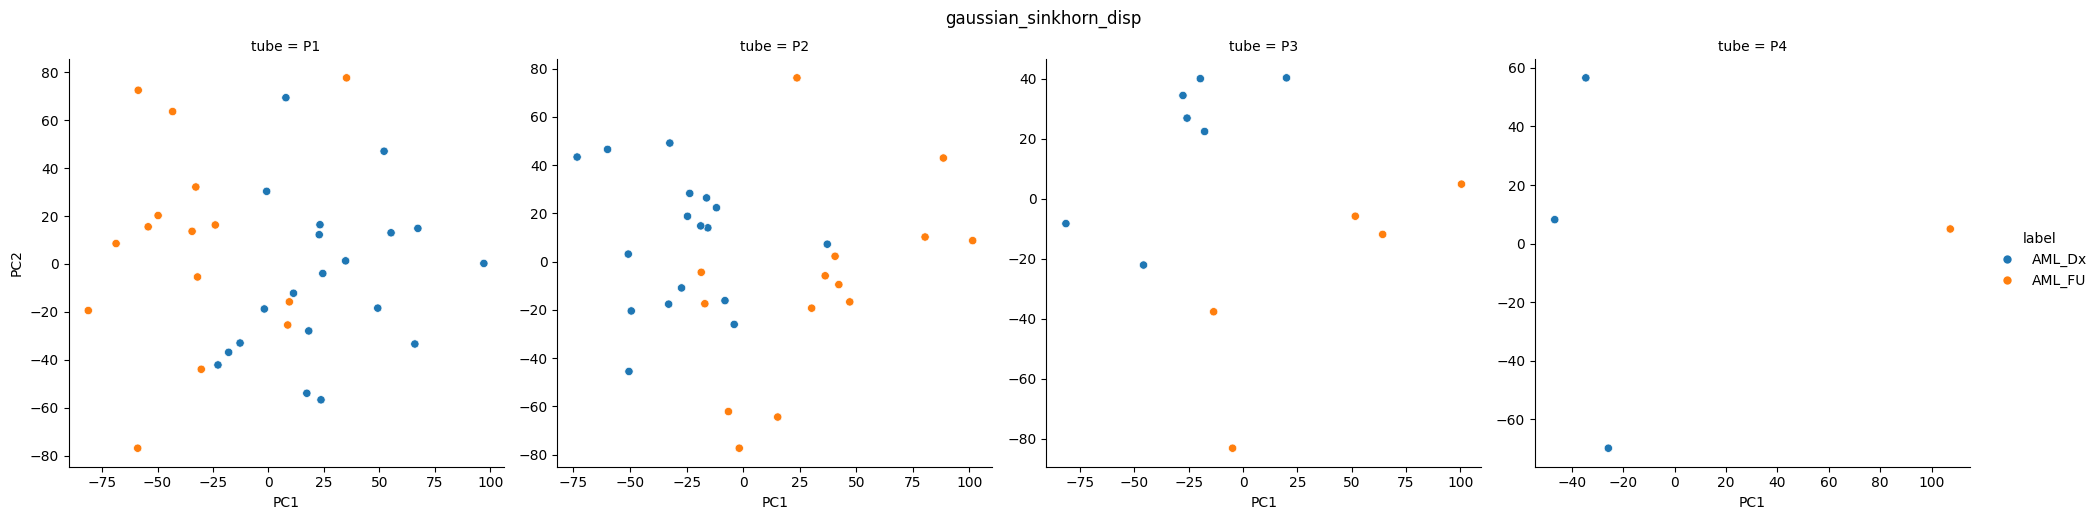

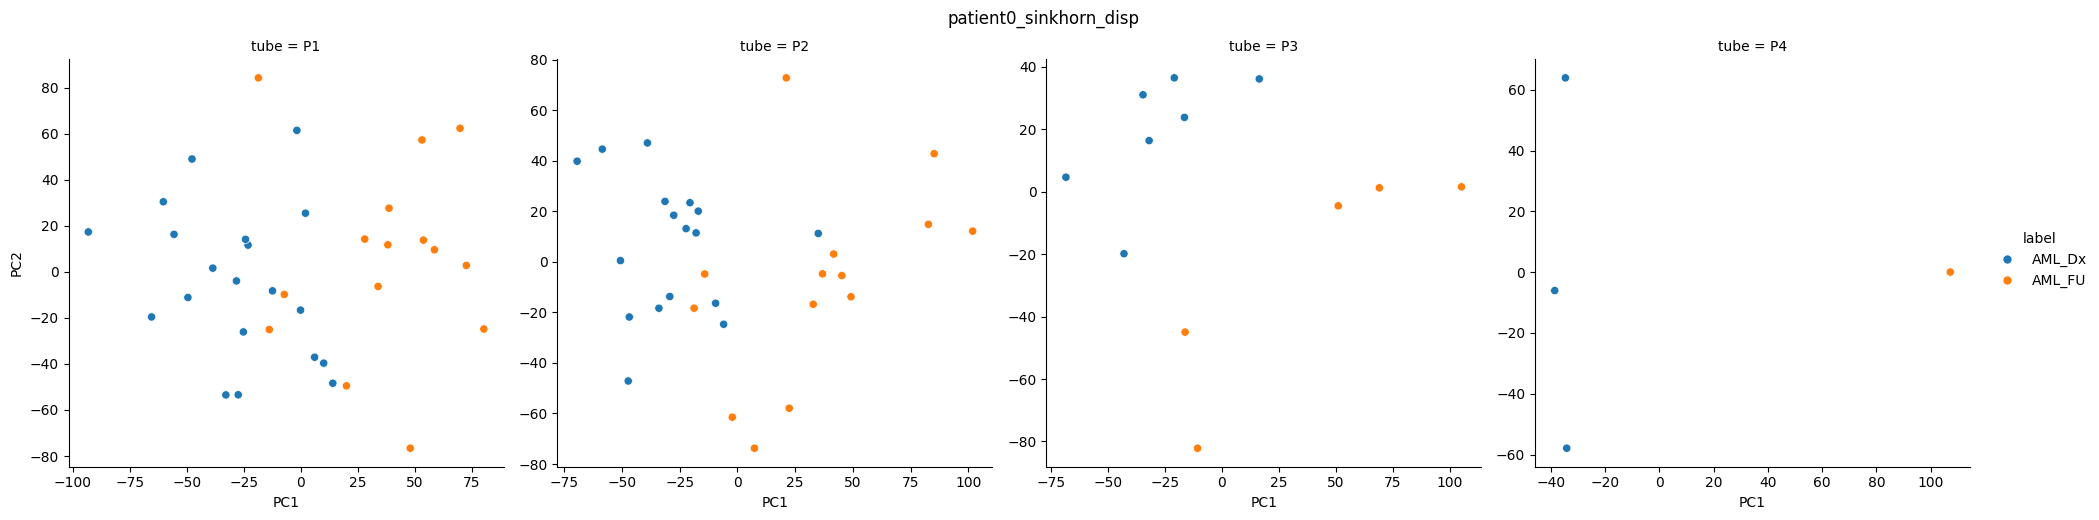

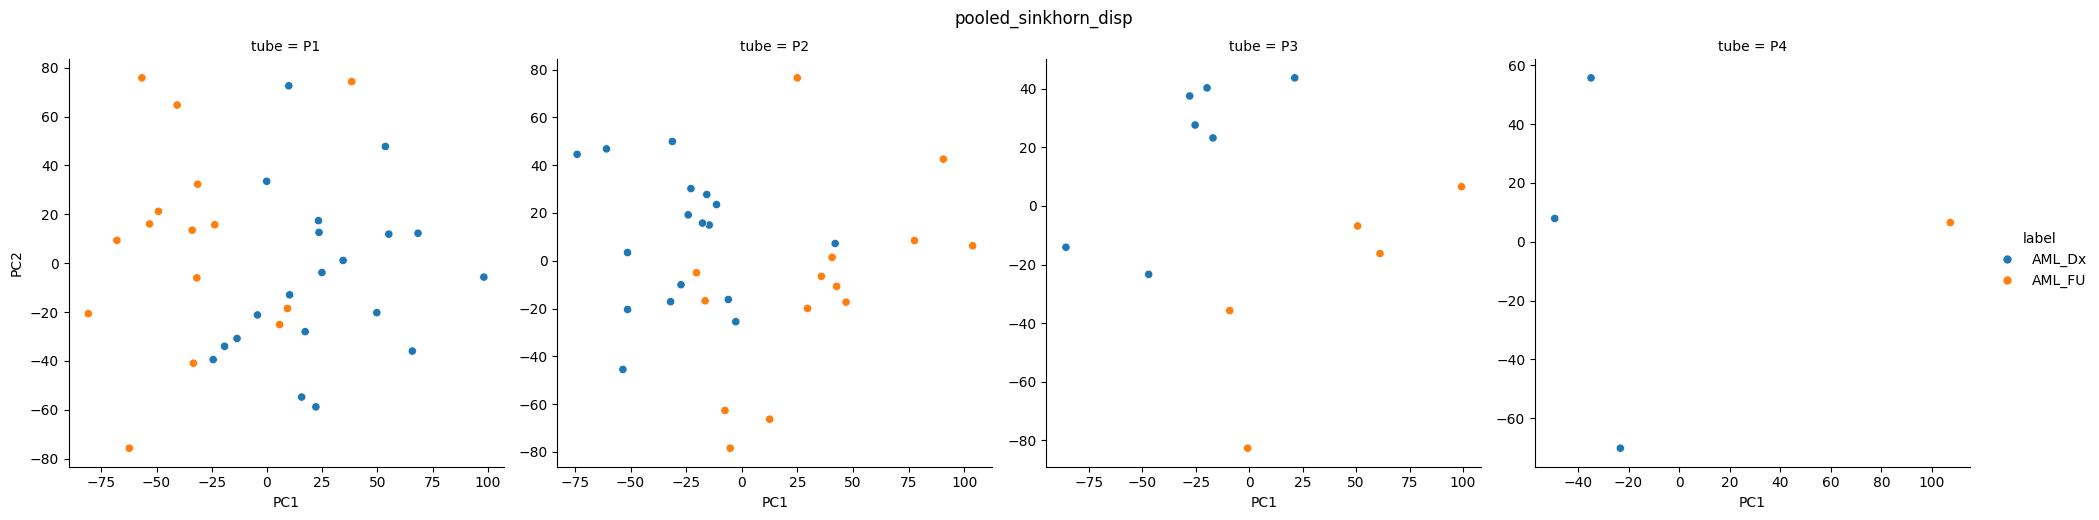

In [ ]:
if not saved.empty:
    with Stage2Loader(STAGE2) as loader:
        for dataset, preprocess in ACTIVE_CONFIGS:
            dataset_saved = saved[
                (saved['dataset'] == dataset) & (saved['preprocess'] == preprocess)
            ]
            for embedding_id in sorted(requested_ids & set(dataset_saved['embedding'])):
                panels = []
                for tube in sorted(dataset_saved.loc[dataset_saved['embedding'] == embedding_id, 'tube']):
                    patient_ids, vectors = loader.embeddings(
                        dataset, CELL_COUNT, tube, preprocess, embedding_id
                    )
                    metadata = loader.metadata(dataset, CELL_COUNT, tube)
                    label_map = dict(zip(metadata['patient_ids'], metadata['labels']))
                    coordinates = PCA(2, random_state=RANDOM_STATE).fit_transform(
                        StandardScaler().fit_transform(vectors)
                    )
                    panels.append(pd.DataFrame({
                        'PC1': coordinates[:, 0], 'PC2': coordinates[:, 1],
                        'patient_id': patient_ids,
                        'label': [label_map[p] for p in patient_ids], 'tube': tube,
                    }))
                if not panels:
                    continue
                plot_data = pd.concat(panels, ignore_index=True)
                grid = sns.relplot(
                    data=plot_data, x='PC1', y='PC2', hue='label', col='tube',
                    kind='scatter', facet_kws={'sharex': False, 'sharey': False},
                )
                grid.figure.suptitle(f'{dataset}: {preprocess}: {embedding_id}', y=1.03)
                plt.show()